In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from numpy.fft import fft2, fftshift

In [15]:
# Read the ground truth image and its corresponding implicit neural representation.
# Transfer to the gray image.
gt_img = io.imread('/home/shizw/Data/Dual-ArbNet/savefigresult/IXI_sin2_gatt_add_fr2/x6.0_6.0/x6.0_6.0_single_fig/IXI016-Guys-0697-T2_55_hr.png', as_gray=True)
gt_img = gt_img.astype(np.float32)

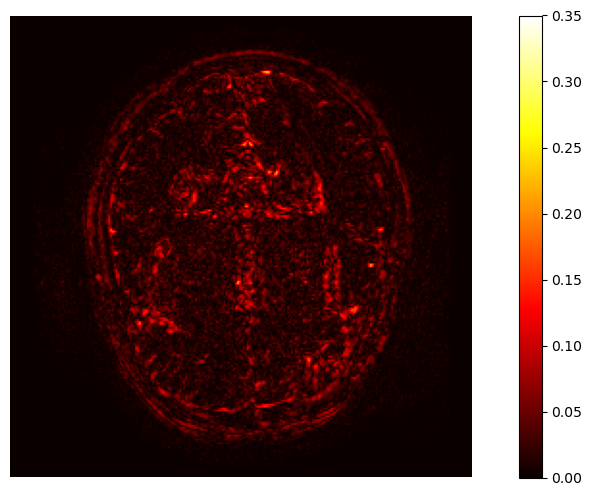

In [17]:
sr_img = io.imread('/home/shizw/Data/Dual-ArbNet/savefigresult/IXI_sin2_gatt_add_fr2/x6.0_6.0/x6.0_6.0_single_fig/IXI016-Guys-0697-T2_55_sr.png', as_gray=True)
sr_img = sr_img.astype(np.float32)

# Compute the residual patch.
# residual = (gt_img - sr_img)/255
residual = abs(gt_img - sr_img)/255
# residual = np.where((gt_img - sr_img) > 0, abs(gt_img - sr_img) / 255, 0)


# Perform a 2D Fourier transform on the residual patch.
# F_residual = fft2(residual)
# # Shift the zero-frequency component to the center.
# F_residual_shifted = fftshift(F_residual)  
# # Take the logarithm to compress the dynamic range.
# magnitude_spectrum_residual = np.log(np.abs(F_residual_shifted) + 1)

# Visualization

plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.imshow(residual, cmap='gray')
plt.imshow(residual, cmap='hot', vmin=0, vmax=0.35)
# plt.title('Residual Image')
plt.axis('off')
# plt.subplot(1, 2, 2)
# plt.imshow(magnitude_spectrum_residual, cmap='jet')  
# plt.title('Frequency Domain of Residual by gatt_add')
plt.colorbar()
plt.axis('off')
plt.gcf().patch.set_alpha(0) 
plt.show()

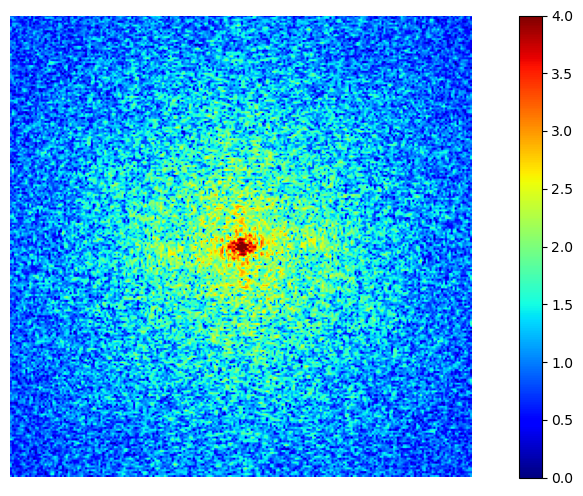

In [19]:
# Perform a 2D Fourier transform on the residual patch.
F_residual = fft2(residual)
# Shift the zero-frequency component to the center.
F_residual_shifted = fftshift(F_residual)  
# Take the logarithm to compress the dynamic range.
magnitude_spectrum_residual = np.log(np.abs(F_residual_shifted) + 1)

# Visualization

plt.figure(figsize=(12, 6))
# plt.imshow(residual, cmap='gray')
# plt.imshow(residual, cmap='hot', vmin=0, vmax=0.35)
# plt.title('Residual Image')
plt.axis('off')
plt.imshow(magnitude_spectrum_residual, cmap='jet', vmin=0, vmax=4)  
# plt.imshow(magnitude_spectrum_residual, cmap='jet')  
# plt.title('Frequency Domain of Residual by gatt_add')
plt.colorbar()
plt.axis('off')
plt.gcf().patch.set_alpha(0) 
plt.show()